# Tiki Kitchen Appliances Market Analytics
## Exploratory Data Analysis (EDA)

Input: `data/processed/products_cleaned.csv`

This notebook explores the cleaned dataset before jumping into KPI
calculation. Each section is loosely mapped to one or more Business
Questions (BQ) defined in `docs/business_questions.md`, but the goal
here is exploration and pattern discovery — final KPI numbers used in the
dashboard are computed separately in `analysis/`.

### Structure
1. Setup & Load
2. Dataset Overview
3. Price Distribution (BQ1.1)
4. Discount Rate Distribution (BQ2)
5. Rating Distribution
6. SKU Count by Brand (BQ3.1 preview)
7. Sub-category Coverage (BQ5 — data limitation note)
8. Discount Rate vs Units Sold (BQ2.1)
9. Rating by Price Bucket (BQ1.3)
10. Units Sold by Discount Bucket (BQ2.1)
11. Rating by Discount Bucket (BQ2.2)
12. Correlation Overview
13. High Reviews, Low Rating (BQ4.1)
14. High Price, Zero Sales
15. Brand Performance Snapshot (BQ3.2 preview)
16. Review-to-Sold Engagement Ratio (BQ4.2)
17. EDA Notes Summary


### 1. Setup & Load

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)

def save_fig(fig, name):
    path = os.path.join(FIG_DIR, name)
    fig.savefig(path, dpi=150, bbox_inches="tight")
    print(f"Saved: {path}")


In [2]:
df = pd.read_csv("../data/processed/products_cleaned.csv")

# price_bucket / discount_bucket were saved as plain strings in CSV;
# restore as ordered categoricals so plots/groupby respect the intended order
price_order = ["<100k", "100-300k", "300-700k", "700k-1.5tr", ">1.5tr"]
discount_order = ["0%", "0-10%", "10-20%", "20-30%", "30-50%", ">50%"]

df["price_bucket"] = pd.Categorical(df["price_bucket"], categories=price_order, ordered=True)
df["discount_bucket"] = pd.Categorical(df["discount_bucket"], categories=discount_order, ordered=True)

print(df.shape)
df.head(3)


(2001, 31)


,id,sku,product_name,price,original_price,discount,discount_rate,rating_average,review_count,quantity_sold_value,inventory_status,inventory_type,brand_id,brand_name,brand_slug,seller_id,seller_name,seller_store_id,category_id,category_name,has_sold,quantity_sold_value_filled,possibly_delisted,reference_price,discount_rate_calc,discount_rate_diff,discount_rate_mismatch,price_bucket,discount_bucket,subcategory_proxy,crawled_review_count
0,359479,1839478484680,Máy Đánh Trứng Bluestone HMB-6333S (300W) - Hà...,551000,829000,278000,34,4.7,1232,12028.0,available,instock,18977,Bluestone,bluestone,1.0,Tiki Trading,40395.0,1882.0,Điện Gia Dụng,True,12028.0,False,829000,33.534379,0.465621,False,300-700k,30-50%,Máy đánh trứng,1245
1,368305,1898506012998,Nồi Cơm Điện Nắp Rời Sharp KSH-D22V - Màu Ngẫu...,756000,950000,194000,20,4.5,40,267.0,available,instock,19912,Sharp,sharp,1.0,Tiki Trading,40395.0,1343.0,CHƯƠNG TRÌNH KHUYẾN MẠI KHÁC,True,267.0,False,950000,20.421053,0.421053,False,700k-1.5tr,10-20%,Nồi cơm điện,48
2,368309,1898129568186,Nồi Cơm Điện Nắp Rời Sharp KSH-D55V (5L) - Trắ...,2061000,2600000,539000,21,4.6,47,248.0,available,instock,19912,Sharp,sharp,1.0,Tiki Trading,40395.0,1882.0,Điện Gia Dụng,True,248.0,False,2600000,20.730769,0.269231,False,>1.5tr,20-30%,Nồi cơm điện,59


### 2. Dataset Overview

In [3]:
df.describe(include="number").T


,count,mean,std,min,25%,50%,75%,max
id,2001.0,2.090531e+08,9.473268e+07,3.594790e+05,1.580986e+08,2.735028e+08,2.766397e+08,2.795794e+08
sku,2001.0,5.266172e+12,2.625581e+12,1.003592e+12,2.901779e+12,5.170482e+12,7.560396e+12,9.988712e+12
price,2001.0,3.168951e+06,6.102263e+06,2.900000e+04,6.950000e+05,1.490000e+06,2.990000e+06,8.502800e+07
original_price,2001.0,3.415962e+06,6.169145e+06,2.900000e+04,8.190000e+05,1.699000e+06,3.490000e+06,8.502800e+07
discount,2001.0,2.468745e+05,6.862607e+05,0.000000e+00,0.000000e+00,0.000000e+00,2.155000e+05,8.890000e+06
discount_rate,2001.0,9.805097e+00,1.633150e+01,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,6.200000e+01
rating_average,2001.0,1.502299e+00,2.190405e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.500000e+00,5.000000e+00
review_count,2001.0,2.373713e+01,2.226427e+02,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,6.567000e+03
quantity_sold_value,1154.0,2.354983e+02,1.583766e+03,0.000000e+00,2.000000e+00,5.000000e+00,2.100000e+01,2.881400e+04
brand_id,2001.0,1.077046e+06,2.179292e+06,1.863400e+04,2.570600e+04,1.454590e+05,4.908170e+05,8.266497e+06


In [4]:
print("Products with recorded sales (has_sold):", df["has_sold"].sum(),
      f"({df['has_sold'].mean() * 100:.1f}%)")
print("Products with at least 1 review:", (df["review_count"] > 0).sum(),
      f"({(df['review_count'] > 0).mean() * 100:.1f}%)")
print("Products flagged possibly_delisted:", df["possibly_delisted"].sum())


Products with recorded sales (has_sold): 1154 (57.7%)
Products with at least 1 review: 655 (32.7%)
Products flagged possibly_delisted: 8


### 3. Price Distribution (BQ1.1)

Where does the category concentrate - cheap, mass-market items, or a
long tail of higher-priced appliances?

Saved: figures\price_distribution.png


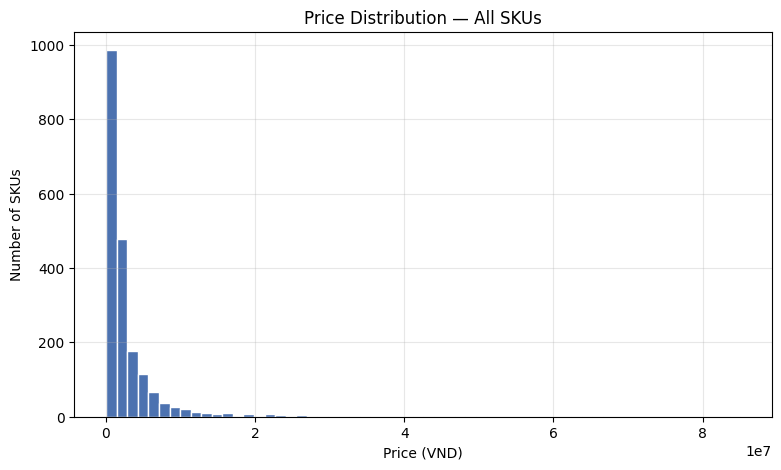

In [5]:
fig, ax = plt.subplots()
ax.hist(df["price"], bins=60, color="#4C72B0", edgecolor="white")
ax.set_xlabel("Price (VND)")
ax.set_ylabel("Number of SKUs")
ax.set_title("Price Distribution — All SKUs")
save_fig(fig, "price_distribution.png")
plt.show()


Saved: figures\sku_count_by_price_bucket.png


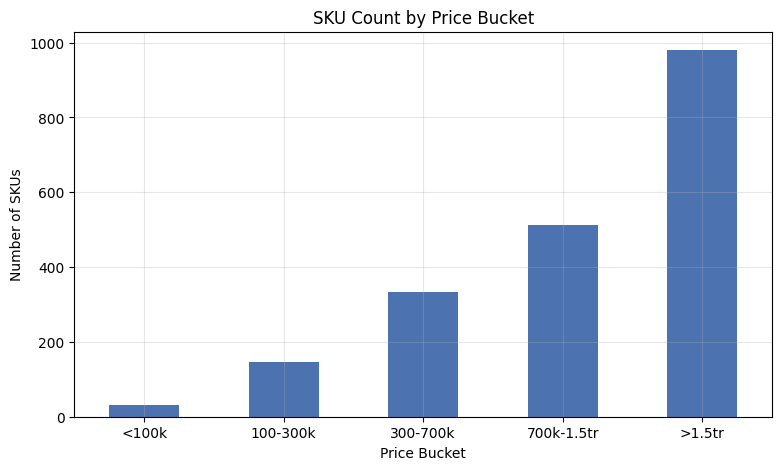

price_bucket
<100k          30
100-300k      145
300-700k      334
700k-1.5tr    512
>1.5tr        980
Name: count, dtype: int64

In [6]:
bucket_counts = df["price_bucket"].value_counts().reindex(price_order)

fig, ax = plt.subplots()
bucket_counts.plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_xlabel("Price Bucket")
ax.set_ylabel("Number of SKUs")
ax.set_title("SKU Count by Price Bucket")
plt.xticks(rotation=0)
save_fig(fig, "sku_count_by_price_bucket.png")
plt.show()

bucket_counts


### 4. Discount Rate Distribution (BQ2)

How aggressively is the category discounted overall?

Saved: figures\discount_rate_distribution.png


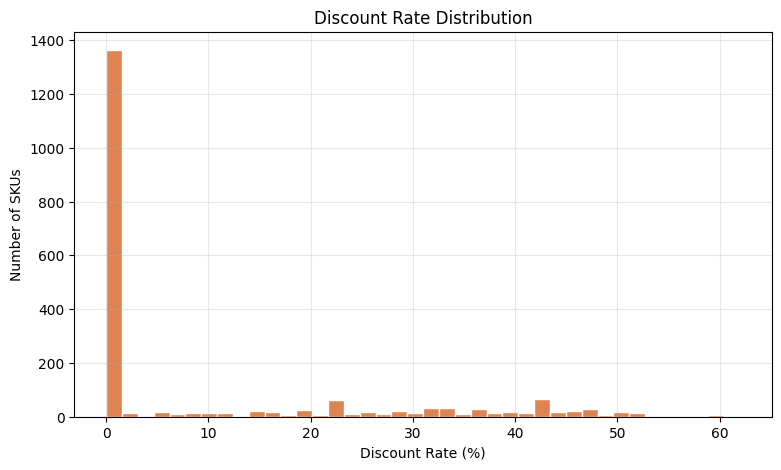

% SKUs currently discounted: 31.9%
Average discount rate (all SKUs): 9.8%
Average discount rate (discounted SKUs only): 30.8%


In [7]:
fig, ax = plt.subplots()
ax.hist(df["discount_rate"], bins=40, color="#DD8452", edgecolor="white")
ax.set_xlabel("Discount Rate (%)")
ax.set_ylabel("Number of SKUs")
ax.set_title("Discount Rate Distribution")
save_fig(fig, "discount_rate_distribution.png")
plt.show()

pct_on_discount = (df["discount_rate"] > 0).mean() * 100
print(f"% SKUs currently discounted: {pct_on_discount:.1f}%")
print(f"Average discount rate (all SKUs): {df['discount_rate'].mean():.1f}%")
print(f"Average discount rate (discounted SKUs only): "
      f"{df.loc[df['discount_rate'] > 0, 'discount_rate'].mean():.1f}%")


### 5. Rating Distribution

Saved: figures\rating_distribution.png


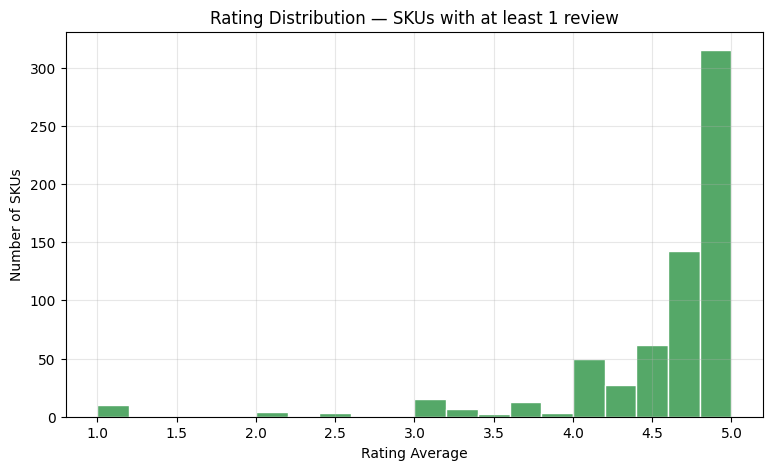

Products excluded (no reviews): 1346
Mean rating (reviewed products only): 4.59


In [8]:
rated = df[df["review_count"] > 0]

fig, ax = plt.subplots()
ax.hist(rated["rating_average"], bins=20, color="#55A868", edgecolor="white")
ax.set_xlabel("Rating Average")
ax.set_ylabel("Number of SKUs")
ax.set_title("Rating Distribution — SKUs with at least 1 review")
save_fig(fig, "rating_distribution.png")
plt.show()

print(f"Products excluded (no reviews): {len(df) - len(rated)}")
print(f"Mean rating (reviewed products only): {rated['rating_average'].mean():.2f}")


### 6. Univariate — SKU Count by Brand (BQ3.1 preview)

Top brands by number of listed SKUs. This is a supply-side view only —
market share by actual units sold is computed properly in the KPI stage
(`05_analysis/`), since SKU count and sales volume can tell very
different stories.

Saved: figures\top_brands_sku_count.png


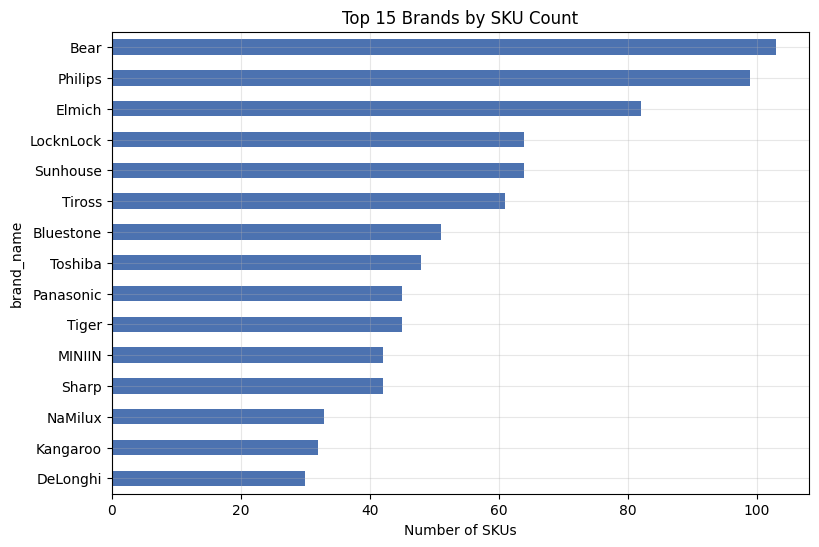

In [9]:
top_brands = df["brand_name"].value_counts().head(15)

fig, ax = plt.subplots(figsize=(9, 6))
top_brands.sort_values().plot(kind="barh", ax=ax, color="#4C72B0")
ax.set_xlabel("Number of SKUs")
ax.set_title("Top 15 Brands by SKU Count")
save_fig(fig, "top_brands_sku_count.png")
plt.show()


### 7. Sub-category Coverage (BQ5 — data limitation)

**Known limitation:** `category_name` in this dataset only reflects the
top-level category ("Điện Gia Dụng") and is constant across all rows —
Tiki's product detail endpoint returns only the top-level category here,
not the specific sub-category (e.g. "Máy xay, máy ép", "Nồi chiên không
dầu").

`subcategory_proxy` is a keyword-based heuristic tagged from
`product_name` (not Tiki's official taxonomy) — computed once in
`03_data_cleaning/cleaning.ipynb` and persisted into
`products_cleaned.csv`, so it is simply read here, not recomputed. This
avoids keeping the same keyword-matching logic in two places, which
would risk the two copies drifting out of sync over time.

In [10]:
print(df["category_name"].value_counts())


category_name
Điện Gia Dụng                   1535
Root                             228
Bình đun siêu tốc                 29
Nồi chiên                         18
Bếp điện từ đơn                   16
Nồi cơm điện tử                   15
Nồi cơm nắp gài                   14
Máy xay cầm tay                   14
Nồi đa năng                       12
Máy xay sinh tố gia đình          11
CHƯƠNG TRÌNH KHUYẾN MẠI KHÁC      10
Nồi lẩu điện                       9
Máy ép chậm                        8
Nồi áp suất điện                   8
Máy làm sữa đậu nành               8
Nồi tiềm, nồi nấu cháo             7
Máy pha cà phê gia đình            6
Bếp điện từ đôi                    6
Máy xay thịt                       6
Máy làm sữa chua                   5
Máy đánh trứng                     3
Máy xay cà phê                     3
Máy xay cắt đa năng                3
Nồi cơm nắp rời                    3
Lò vi sóng cơ                      3
Máy ép nhanh                       2
Bếp hồng ngoại đơn      

Unclassified rate: 15.4%
Saved: figures\subcategory_proxy_sku_count.png


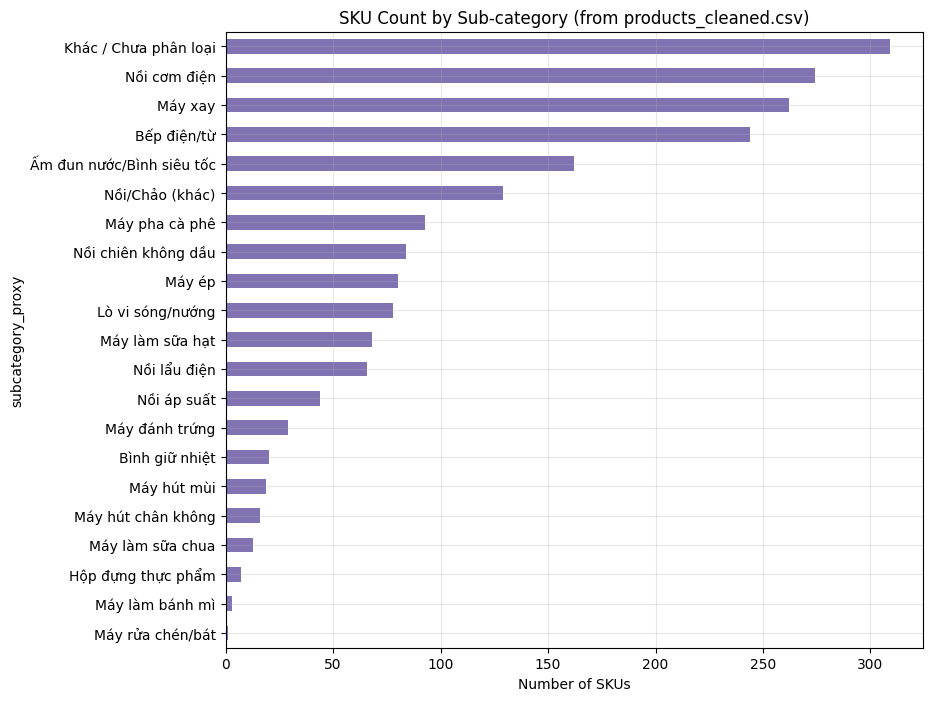

subcategory_proxy
Khác / Chưa phân loại        309
Nồi cơm điện                 274
Máy xay                      262
Bếp điện/từ                  244
Ấm đun nước/Bình siêu tốc    162
Nồi/Chảo (khác)              129
Máy pha cà phê                93
Nồi chiên không dầu           84
Máy ép                        80
Lò vi sóng/nướng              78
Máy làm sữa hạt               68
Nồi lẩu điện                  66
Nồi áp suất                   44
Máy đánh trứng                29
Bình giữ nhiệt                20
Máy hút mùi                   19
Máy hút chân không            16
Máy làm sữa chua              13
Hộp đựng thực phẩm             7
Máy làm bánh mì                3
Máy rửa chén/bát               1
Name: count, dtype: int64

In [11]:
subcat_counts = df["subcategory_proxy"].value_counts()
unclassified_pct = (df["subcategory_proxy"] == "Khác / Chưa phân loại").mean() * 100
print(f"Unclassified rate: {unclassified_pct:.1f}%")

fig, ax = plt.subplots(figsize=(9, 8))
subcat_counts.sort_values().plot(kind="barh", ax=ax, color="#8172B2")
ax.set_xlabel("Number of SKUs")
ax.set_title("SKU Count by Sub-category (from products_cleaned.csv)")
save_fig(fig, "subcategory_proxy_sku_count.png")
plt.show()

subcat_counts


### 8. Bivariate — Discount Rate vs Units Sold (BQ2.1)

Does discounting actually move volume, and if so, up to what point?

Saved: figures\discount_vs_units_sold_scatter.png


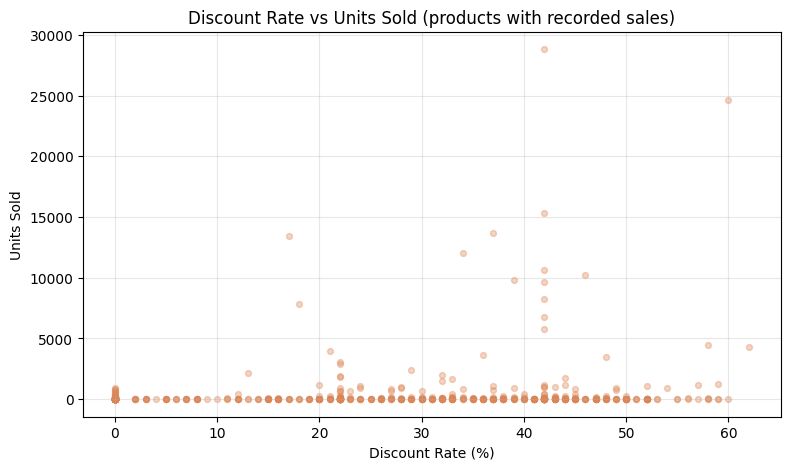

In [12]:
plot_df = df[df["has_sold"]]

fig, ax = plt.subplots()
ax.scatter(plot_df["discount_rate"], plot_df["quantity_sold_value"],
           alpha=0.35, s=18, color="#DD8452")
ax.set_xlabel("Discount Rate (%)")
ax.set_ylabel("Units Sold")
ax.set_title("Discount Rate vs Units Sold (products with recorded sales)")
save_fig(fig, "discount_vs_units_sold_scatter.png")
plt.show()


Saved: figures\avg_units_sold_by_discount_bucket.png


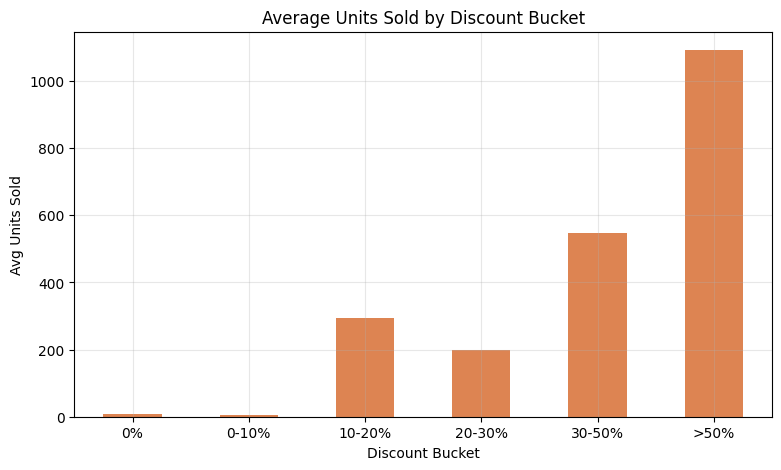

discount_bucket
0%           8.818048
0-10%        5.184615
10-20%     294.511364
20-30%     199.787671
30-50%     546.398026
>50%      1091.942857
Name: quantity_sold_value_filled, dtype: float64

In [13]:
avg_sold_by_discount = (
    df.groupby("discount_bucket", observed=True)["quantity_sold_value_filled"]
    .mean()
    .reindex(discount_order)
)

fig, ax = plt.subplots()
avg_sold_by_discount.plot(kind="bar", ax=ax, color="#DD8452")
ax.set_xlabel("Discount Bucket")
ax.set_ylabel("Avg Units Sold")
ax.set_title("Average Units Sold by Discount Bucket")
plt.xticks(rotation=0)
save_fig(fig, "avg_units_sold_by_discount_bucket.png")
plt.show()

avg_sold_by_discount


### 9. Bivariate — Rating by Price Bucket (BQ1.3)

C:\Users\Xuan Tu\AppData\Local\Temp\ipykernel_19848\4002450798.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=price_order, showmeans=True)


Saved: figures\rating_by_price_bucket_boxplot.png


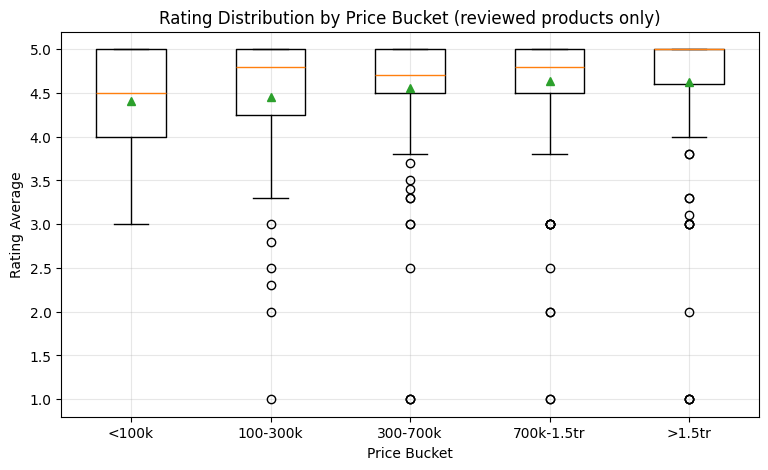

In [14]:
groups = [rated.loc[rated["price_bucket"] == b, "rating_average"].dropna()
           for b in price_order]

fig, ax = plt.subplots()
ax.boxplot(groups, labels=price_order, showmeans=True)
ax.set_xlabel("Price Bucket")
ax.set_ylabel("Rating Average")
ax.set_title("Rating Distribution by Price Bucket (reviewed products only)")
save_fig(fig, "rating_by_price_bucket_boxplot.png")
plt.show()


### 10. Bivariate — Units Sold by Discount Bucket (BQ2.1)

C:\Users\Xuan Tu\AppData\Local\Temp\ipykernel_19848\2556353473.py:6: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=discount_order, showmeans=True, showfliers=False)


Saved: figures\units_sold_by_discount_bucket_boxplot.png


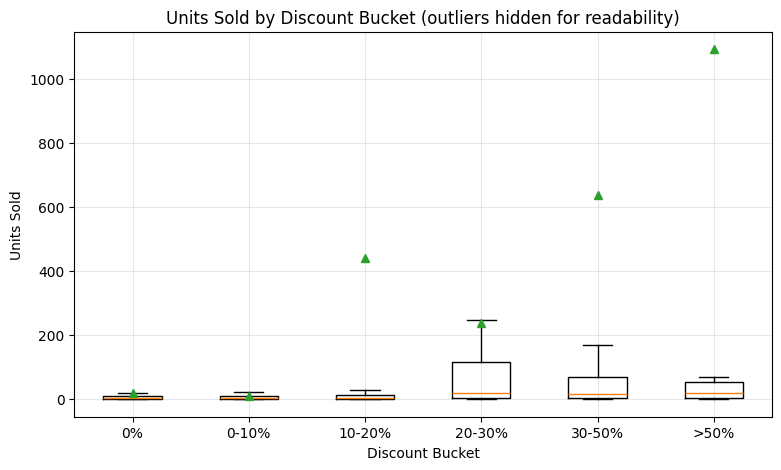

In [15]:
sold_only = df[df["has_sold"]]
groups = [sold_only.loc[sold_only["discount_bucket"] == b, "quantity_sold_value"].dropna()
          for b in discount_order]

fig, ax = plt.subplots()
ax.boxplot(groups, labels=discount_order, showmeans=True, showfliers=False)
ax.set_xlabel("Discount Bucket")
ax.set_ylabel("Units Sold")
ax.set_title("Units Sold by Discount Bucket (outliers hidden for readability)")
save_fig(fig, "units_sold_by_discount_bucket_boxplot.png")
plt.show()


### 11. Bivariate — Rating by Discount Bucket (BQ2.2)

C:\Users\Xuan Tu\AppData\Local\Temp\ipykernel_19848\1717286325.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(groups, labels=discount_order, showmeans=True)


Saved: figures\rating_by_discount_bucket_boxplot.png


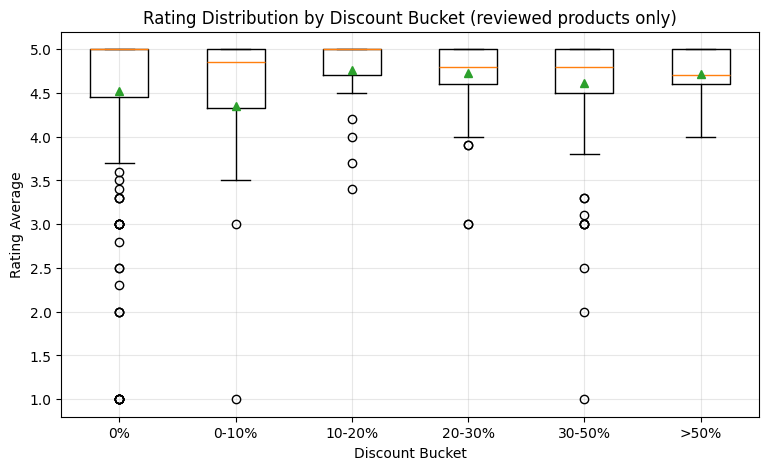

In [16]:
groups = [rated.loc[rated["discount_bucket"] == b, "rating_average"].dropna()
           for b in discount_order]

fig, ax = plt.subplots()
ax.boxplot(groups, labels=discount_order, showmeans=True)
ax.set_xlabel("Discount Bucket")
ax.set_ylabel("Rating Average")
ax.set_title("Rating Distribution by Discount Bucket (reviewed products only)")
save_fig(fig, "rating_by_discount_bucket_boxplot.png")
plt.show()


### 12. Correlation Overview

Saved: figures\correlation_matrix.png


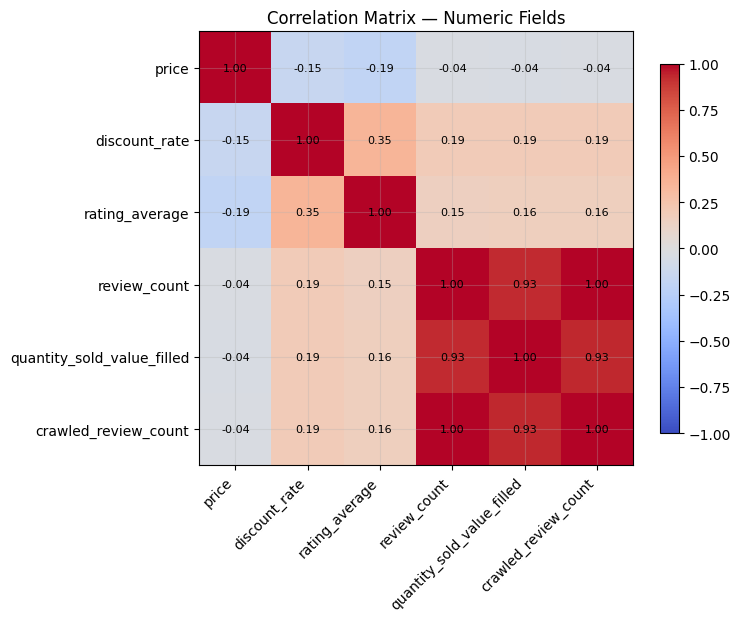

In [17]:
corr_cols = ["price", "discount_rate", "rating_average", "review_count",
             "quantity_sold_value_filled", "crawled_review_count"]

corr = df[corr_cols].corr(numeric_only=True)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
ax.set_xticks(range(len(corr_cols)))
ax.set_yticks(range(len(corr_cols)))
ax.set_xticklabels(corr_cols, rotation=45, ha="right")
ax.set_yticklabels(corr_cols)
for i in range(len(corr_cols)):
    for j in range(len(corr_cols)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)
fig.colorbar(im, ax=ax, shrink=0.8)
ax.set_title("Correlation Matrix — Numeric Fields")
save_fig(fig, "correlation_matrix.png")
plt.show()


### 13. Anomaly — High Reviews, Low Rating (BQ4.1)

Products with a meaningful review volume but a low average rating are a
quality-risk watchlist candidate.

In [18]:
REVIEW_THRESHOLD = df["review_count"].quantile(0.75)  # top-quartile review volume
RATING_THRESHOLD = 3.5

risk_watchlist = df[
    (df["review_count"] >= REVIEW_THRESHOLD) & (df["rating_average"] < RATING_THRESHOLD)
].sort_values("review_count", ascending=False)

print(f"Review count threshold (75th percentile): {REVIEW_THRESHOLD:.0f}")
print(f"Products flagged: {len(risk_watchlist)}")
risk_watchlist[["id", "product_name", "brand_name", "rating_average", "review_count"]].head(15)


Review count threshold (75th percentile): 1
Products flagged: 41


,id,product_name,brand_name,rating_average,review_count
471,144162573,[Loại Tốt] Máy Hút Chân Không KhoNCC Hàng Chín...,KHONCC,3.4,22
102,1826509,Nồi Cơm Điện Nắp Gài Sharp KS-19TJVBC (1.8L) -...,Sharp,3.4,9
135,7285805,Nồi Cơm Điện Cao Tần Kangaroo KG599N (1.8L) - ...,Kangaroo,3.1,8
1874,278850217,Máy xay cầm tay Bear SB-MX04K - Hàng Chính Hãng,Bear,3.3,7
1594,277487800,"Ấm Siêu Tốc Văn Phòng Mini Thái Lan 0,8L - Bìn...",KORENO,2.8,4
531,167925176,"Hộp cơm cắm điện hai tầng, hộp cơm hâm nóng 2...",KitAcoom,2.3,3
196,26020574,Bếp Dương Từ Đôi Proficook PC-DKI 1067 (3500W)...,Proficook,3.3,3
1533,276930198,"Máy Nhổ Lông Gà Vịt Cầm Tay – Chạy Pin, Đa Năn...",MINIIN,3.3,3
1000,273502846,"Ấm siêu tốc mini Bennix 2 lớp cao cấp 0.6L, sô...",Bennix,3.3,3
573,177924749,Máy xay sinh tố cầm tay Bear LLJ-B03C1 - Hàng ...,Bear,3.0,3


### 14. Anomaly — High Price, Zero Sales

In [19]:
PRICE_THRESHOLD = df["price"].quantile(0.75)

high_price_no_sales = df[
    (df["price"] >= PRICE_THRESHOLD) & (~df["has_sold"])
].sort_values("price", ascending=False)

print(f"Price threshold (75th percentile): {PRICE_THRESHOLD:,.0f} VND")
print(f"High-price products with zero recorded sales: {len(high_price_no_sales)}")
high_price_no_sales[["id", "product_name", "brand_name", "price"]].head(15)


Price threshold (75th percentile): 2,990,000 VND
High-price products with zero recorded sales: 366


,id,product_name,brand_name,price
694,201391241,Máy pha cà phê Expobar G10 Display 2Gr - Hàng ...,Expobar,85028000
1065,274252396,[CỬA HÀNG CHÍNH HÃNG] Máy làm kem tươi cao cấp...,Fushimavina,66000000
1276,275697850,[HÀNG CHÍNH HÃNG] Máy làm kem tươi 2 máy nén d...,VinER,66000000
1251,275591754,[CỬA HÀNG CHÍNH HÃNG] Bếp từ công nghiệp đôi 1...,Fushimavina,63800000
681,200681523,Máy pha cà phê tự động Jura WE8 Chrome - Hàng ...,JURA,63515000
551,173124885,Lò nướng bánh Unox XEFT-04HS-ETDP - Hàng nhập ...,UNOX,57660000
693,201385286,Máy pha cà phê Expobar G10 Mini Control 1Gr - ...,Expobar,57088000
1281,275728931,[CỬA HÀNG CHÍNH HÃNG] Máy làm kem tươi cao cấp...,Fushimavina,50000000
1830,278824371,Máy trộn bột đa năng Smeg 50's Retro Style SMF...,Smeg,50000000
1282,275729060,[CỬA HÀNG CHÍNH HÃNG] Máy làm kem tươi cao cấp...,Fushimavina,50000000


### 15. Brand Performance Snapshot (BQ3.2 preview)

Quick look at SKU count vs total units sold per brand, to spot brands
that look small by SKU count but move meaningful volume (or vice versa).
Full market-share KPI calculation happens in `05_analysis/`.

Saved: figures\brand_sku_vs_sold_snapshot.png


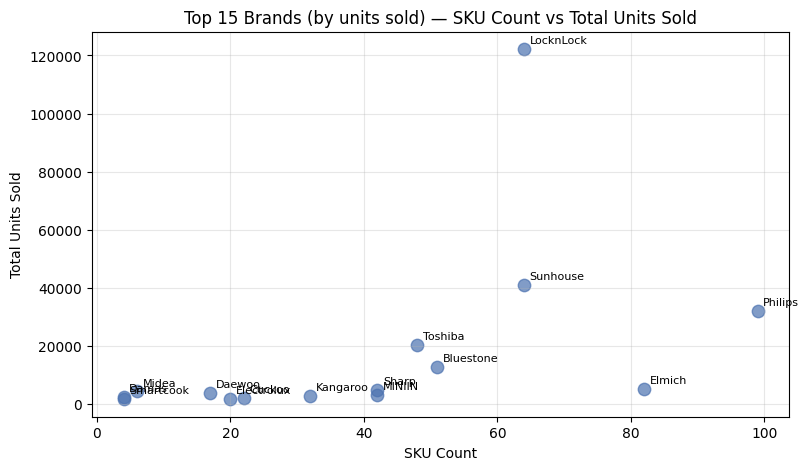

,sku_count,total_sold,avg_rating
brand_name,,,
LocknLock,64,122146.0,3.404688
Sunhouse,64,40886.0,1.709375
Philips,99,32022.0,1.784848
Toshiba,48,20373.0,3.070833
Bluestone,51,12673.0,1.292157
Elmich,82,5042.0,3.040244
Sharp,42,4907.0,2.245238
Midea,6,4325.0,1.766667
Daewoo,17,3826.0,2.741176


In [20]:
brand_snapshot = (
    df.groupby("brand_name")
    .agg(
        sku_count=("id", "count"),
        total_sold=("quantity_sold_value_filled", "sum"),
        avg_rating=("rating_average", "mean"),
    )
    .sort_values("total_sold", ascending=False)
)

top15 = brand_snapshot.head(15)

fig, ax = plt.subplots()
ax.scatter(top15["sku_count"], top15["total_sold"], s=80, alpha=0.7, color="#4C72B0")
for brand, row in top15.iterrows():
    ax.annotate(brand, (row["sku_count"], row["total_sold"]), fontsize=8,
                xytext=(4, 4), textcoords="offset points")
ax.set_xlabel("SKU Count")
ax.set_ylabel("Total Units Sold")
ax.set_title("Top 15 Brands (by units sold) — SKU Count vs Total Units Sold")
save_fig(fig, "brand_sku_vs_sold_snapshot.png")
plt.show()

top15


### 16. Review-to-Sold Engagement Ratio (BQ4.2)

How willing are customers to leave a review relative to how many units
are sold, and does this vary by price segment?

Saved: figures\review_to_sold_ratio_by_price_bucket.png


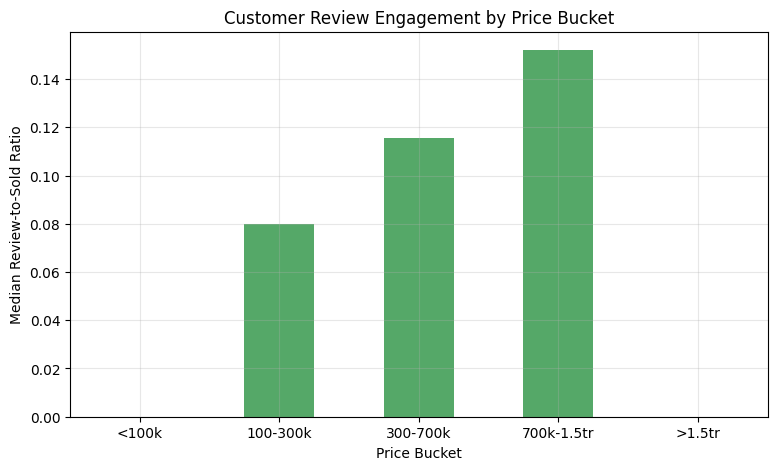

price_bucket
<100k         0.000000
100-300k      0.080000
300-700k      0.115380
700k-1.5tr    0.152017
>1.5tr        0.000000
Name: review_to_sold_ratio, dtype: float64

In [21]:
engaged = df[df["has_sold"] & (df["quantity_sold_value"] > 0)].copy()
engaged["review_to_sold_ratio"] = (
    engaged["crawled_review_count"] / engaged["quantity_sold_value"]
)

ratio_by_bucket = (
    engaged.groupby("price_bucket", observed=True)["review_to_sold_ratio"]
    .median()
    .reindex(price_order)
)

fig, ax = plt.subplots()
ratio_by_bucket.plot(kind="bar", ax=ax, color="#55A868")
ax.set_xlabel("Price Bucket")
ax.set_ylabel("Median Review-to-Sold Ratio")
ax.set_title("Customer Review Engagement by Price Bucket")
plt.xticks(rotation=0)
save_fig(fig, "review_to_sold_ratio_by_price_bucket.png")
plt.show()

ratio_by_bucket


### 17. EDA Notes Summary

In [22]:
notes = f'''
EDA Summary Notes
==================
- {df['has_sold'].mean() * 100:.1f}% of SKUs have at least one recorded sale.
- {pct_on_discount:.1f}% of SKUs are currently discounted; average discount
  among discounted SKUs is {df.loc[df["discount_rate"] > 0, "discount_rate"].mean():.1f}%.
- {len(risk_watchlist)} products flagged on the quality-risk watchlist
  (top-quartile review volume, rating < {RATING_THRESHOLD}).
- {len(high_price_no_sales)} high-price products (top price quartile) show
  zero recorded sales — worth checking for pricing or listing issues.
- category_name is constant (top-level only) in this dataset — BQ5
  (sub-category assortment gap) uses a keyword-based proxy
  (subcategory_proxy) as an interim workaround; recommend re-crawling
  breadcrumbs for a production-grade version.
'''

print(notes)

with open("eda_notes.md", "w", encoding="utf-8") as f:
    f.write(notes)



EDA Summary Notes
- 57.7% of SKUs have at least one recorded sale.
- 31.9% of SKUs are currently discounted; average discount
  among discounted SKUs is 30.8%.
- 41 products flagged on the quality-risk watchlist
  (top-quartile review volume, rating < 3.5).
- 366 high-price products (top price quartile) show
  zero recorded sales — worth checking for pricing or listing issues.
- category_name is constant (top-level only) in this dataset — BQ5
  (sub-category assortment gap) uses a keyword-based proxy
  (subcategory_proxy) as an interim workaround; recommend re-crawling
  breadcrumbs for a production-grade version.

